In [7]:
import pandas as pd 
import numpy as np 
dataset= pd.read_csv(r'C:\Users\JONAH A\Downloads\Telco-Customer-Churn.csv')
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print(dataset.isnull().sum())
print(dataset.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\JONAH A\AppData\Local\Temp\ipykernel_19620\1075330392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=dataset,palette='coolwarm')


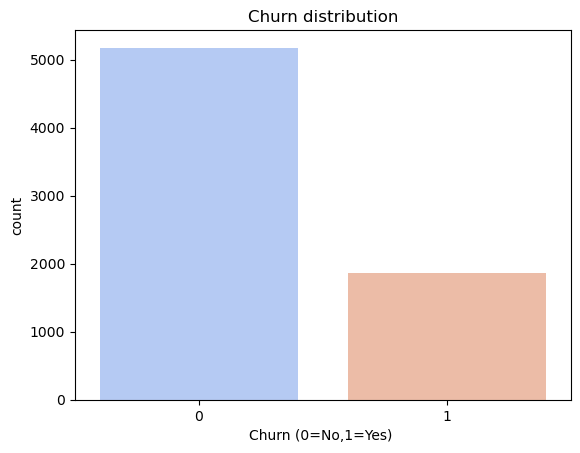

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

print(dataset['Churn'].value_counts())
sns.countplot(x='Churn',data=dataset,palette='coolwarm')
plt.title('Churn distribution')
plt.xlabel('Churn (0=No,1=Yes) ')
plt.ylabel('count')
plt.show()

In [54]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'].fillna(dataset['TotalCharges'].median(), inplace=True)

C:\Users\JONAH A\AppData\Local\Temp\ipykernel_19620\266048525.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['TotalCharges'].fillna(dataset['TotalCharges'].median(), inplace=True)


In [72]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
categorial_cols=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']
for col in categorial_cols:
    dataset[col]= labelencoder.fit_transform(dataset[col])

In [82]:
from sklearn.model_selection  import train_test_split
x=dataset.drop(['customerID','Churn'],axis=1)
y=dataset['Churn']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=0)
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2920,0,0,1,0,72,1,0,0,2,2,2,2,2,2,2,0,3,85.10,6155.40
2966,0,1,0,0,14,0,1,0,0,0,0,0,2,2,0,1,2,46.35,672.70
6099,0,0,1,1,71,1,2,2,1,1,1,1,1,1,2,0,0,24.70,1810.55
5482,1,0,1,1,33,1,0,0,0,0,2,2,2,2,1,1,3,73.90,2405.05
2012,0,0,1,0,47,1,2,1,2,2,2,0,2,0,0,1,2,98.75,4533.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,1,0,1,0,15,1,2,1,0,0,2,2,2,2,0,1,2,103.45,1539.80
3264,0,0,0,1,10,1,0,1,0,0,2,2,2,0,0,1,2,91.10,964.35
1653,1,0,1,0,58,1,0,2,1,1,1,1,1,1,2,0,3,20.75,1185.95
2607,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.75,69.75


In [88]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_train
x_test

array([[-1.        , -0.4397627 , -0.96854556, ...,  0.39281573,
        -0.22069469, -0.54691104],
       [ 1.        , -0.4397627 , -0.96854556, ..., -0.54099179,
         1.72202508,  2.09892224],
       [-1.        , -0.4397627 , -0.96854556, ...,  0.39281573,
         0.23670937, -0.60040717],
       ...,
       [-1.        ,  2.27395367, -0.96854556, ...,  0.39281573,
         1.56733934,  1.82104199],
       [ 1.        , -0.4397627 , -0.96854556, ...,  1.32662326,
        -0.2855629 , -0.58013681],
       [ 1.        , -0.4397627 , -0.96854556, ...,  1.32662326,
        -0.63318998, -0.98732875]])

In [100]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(x_train, y_train)
    
y_pred = clf.predict(x_test)

In [102]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.79


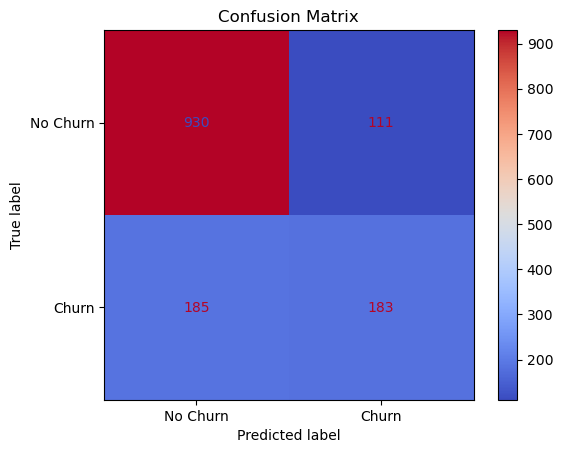

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()